In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [22]:
df=pd.read_csv('credit_card_data.csv')
df.head()

,CustID,Balance,Purchases,CashAdvance,CreditLimit,Payments
0,C101,1200.5,500.0,0.0,5000,450.2
1,C102,3200.2,120.0,1500.5,4000,300.0
2,C103,50.2,2500.7,0.0,7000,2400.0
3,C104,8900.0,0.0,6500.0,10000,1200.0
4,C105,150.0,450.0,0.0,2000,400.5


In [28]:
df_numeric=df.select_dtypes(['float64','int64'])
ss=StandardScaler()

In [29]:
scaled_data=ss.fit_transform(df_numeric)

In [39]:
#calculate wcss
wcss=[]
for k in range(1,10):
    model=KMeans(n_clusters=k,random_state=42)
    model.fit(scaled_data)
    wcss.append(model.inertia_)

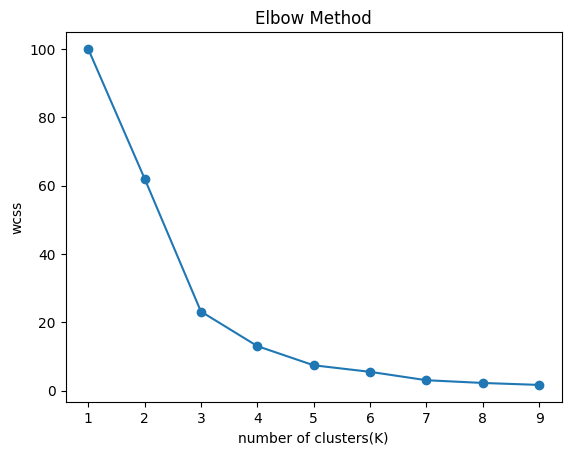

In [40]:
#Elbow method
plt.plot(range(1,10),wcss,marker='o')
plt.xlabel("number of clusters(K)")
plt.ylabel("wcss")
plt.title("Elbow Method")
plt.show()

In [45]:
for k in range(2,7):
    model=KMeans(n_clusters=k,random_state=42)
    labels = model.fit_predict(scaled_data)
    score = silhouette_score(scaled_data, labels)
    print(f"Silhouette Score for K={k}: {score:.4f}")

Silhouette Score for K=2: 0.5396
Silhouette Score for K=3: 0.5388
Silhouette Score for K=4: 0.5166
Silhouette Score for K=5: 0.4698
Silhouette Score for K=6: 0.4388


In [47]:
scores=[]
for k in range(2,7):
    model=KMeans(n_clusters=k,random_state=42).fit_predict(scaled_data)
    scores.append(silhouette_score(scaled_data,model))
print(range(2,7)[scores.index(max(scores))])


2


In [ ]:
#Before Clustering Visualization

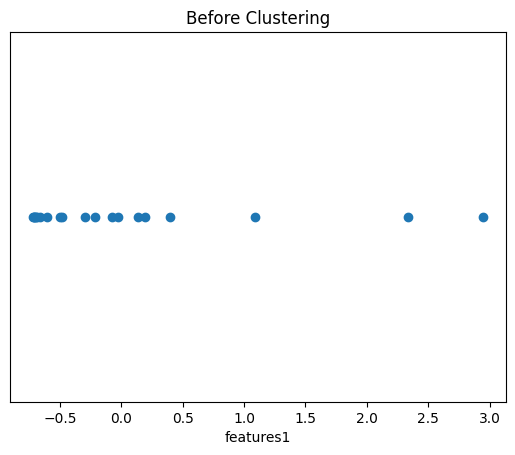

In [52]:
plt.figure()
plt.scatter(scaled_data[:,0],[0]*len(df))
plt.xlabel("features1")
plt.yticks([])
plt.title("Before Clustering")
plt.show()

In [48]:
model=KMeans(n_clusters=2,random_state=42)
df['Clusters']=model.fit_predict(scaled_data)
centroids=model.cluster_centers_

In [50]:
df['Clusters'].values

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0],
      dtype=int32)

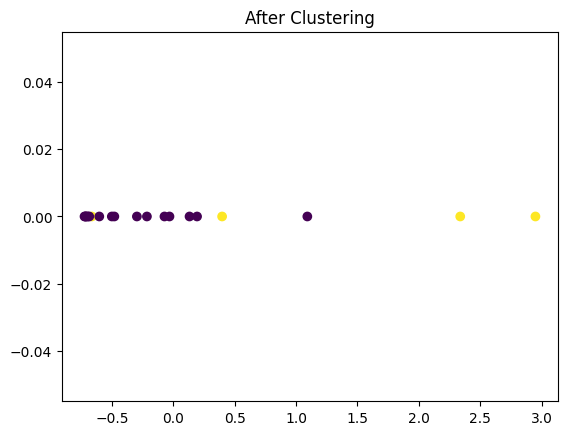

In [60]:
#After Clustering Visualization
plt.figure()
plt.scatter(scaled_data[:,0],[0]*len(df),c=df['Clusters'])

#plt.scatter(centroids[:,0],[0]*len(centroids),marker='h')
plt.title("After Clustering")
plt.show()

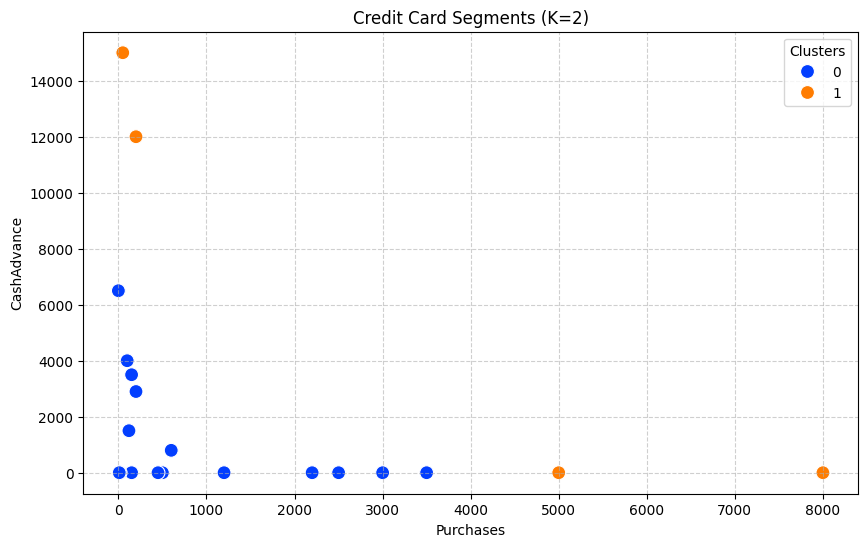

In [59]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Purchases', y='CashAdvance', hue='Clusters', palette='bright', s=100)
plt.title(f'Credit Card Segments (K=2)')
plt.show()

In [56]:
#Silhouette Score
silhouette_score(scaled_data,df['Clusters'])

0.539550518105448